### Mathematical Formulation
Let the raw tick stream be defined as a sequence of tuples $\{(p_i, v_i)\}_{i=1}^N$, representing the price and volume of the $i$-th transaction. We define the $k$-th bar as containing the sequence of ticks $i \in [T_{k-1} + 1, T_k]$.The index $T_k$ is determined by an arbitrary threshold $\theta$:Tick Bars: Sample when a fixed number of transactions have occurred.$$T_k = \min \left\{ t : \sum_{i=T_{k-1}+1}^t 1 \geq \theta_T \right\}$$Volume Bars: Sample when a fixed number of shares/contracts have been traded.$$T_k = \min \left\{ t : \sum_{i=T_{k-1}+1}^t v_i \geq \theta_V \right\}$$Dollar Bars: Sample when a fixed fiat value has been exchanged. This is generally the most robust of the three, as it naturally adjusts for significant price changes, stock splits, and inflation.$$T_k = \min \left\{ t : \sum_{i=T_{k-1}+1}^t p_i v_i \geq \theta_D \right\}$$

In [1]:
import pandas as pd


def load_data_from_csv(csv_file: str) -> pd.DataFrame:
    # yfinance CSV export uses a 2-row header for MultiIndex columns and a standalone index-name row.
    # data = pd.read_csv(csv_file, header=[0, 1], skiprows=[2], index_col=0)

    # data.index = pd.to_datetime(data.index)
    # data.index.name = "timestamp"
    df = pd.read_csv(csv_file, parse_dates=['timestamp'])
    df.sort_values('timestamp', inplace=True)

    return df


output_file = r"G:\Mi unidad\2026\Tesis\Códigos\Data\sp500_2015_to_2025_1Min.csv"

df = load_data_from_csv(output_file)

Standard bars sample the market based on the total magnitude of activity, indiscriminately grouping buyer-initiated and seller-initiated flow.Tick Threshold ($\theta_T$): Measures algorithmic fragmentation.$$\theta_{T, t+1} = \mathbb{E}[\text{Trades}_t]$$Trigger: Accumulator breaches $\theta_T$.Volume Threshold ($\theta_V$): Measures share turnover.$$\theta_{V, t+1} = \mathbb{E}[V_t]$$Trigger: Accumulator breaches $\theta_V$.Dollar Threshold ($\theta_D$): Measures fiat capital commitment (Risk Transfer). This is the most stable standard metric.$$\theta_{D, t+1} = \mathbb{E}[P_t \cdot V_t]$$Trigger: Accumulator breaches $\theta_D$.B. 

In [282]:
import numpy as np
import pandas as pd


def form_bars(
    df: pd.DataFrame,
    bar_type: str,
    ewma_window: int = 100,
) -> pd.DataFrame:
    """
    Forms standard or imbalance bars using Prado's exact conditional
    expectation formulation via an autonomous event-driven state machine.

    Daily calibration policy for 1-minute ticks:
    - Compute mean ticks per day from all dates.
    - Burn-in uses round(ewma_window * mean_ticks_per_day) ticks.
    - Standard-bar threshold is mean_ticks_per_day * EWMA(magnitude per tick).
    - Bars start strictly after burn-in.
    """
    _EMPTY = pd.DataFrame(columns=["Open", "High", "Low", "Close", "Volume", "VWAP"])

    if df.empty:
        return _EMPTY

    # ------------------------------------------------------------------
    # 1. Resolve bar type & identify the seed metric
    # ------------------------------------------------------------------
    bt = bar_type.strip().lower()
    is_imbalance = "imbalance" in bt

    if is_imbalance:
        base_metric = "dollar"
    else:
        if bt not in {"tick", "volume", "dollar"}:
            raise ValueError("bar_type must be one of: 'tick', 'volume', 'dollar', 'imbalance'")
        base_metric = bt

    # ------------------------------------------------------------------
    # 2. Daily calibration & burn-in length in ticks
    # ------------------------------------------------------------------
    ts = pd.to_datetime(df["timestamp"])
    ticks_per_day = ts.dt.normalize().value_counts().astype(float)
    if ticks_per_day.empty:
        return _EMPTY

    mean_ticks_per_day = float(ticks_per_day.mean())
    if not np.isfinite(mean_ticks_per_day) or mean_ticks_per_day <= 0:
        return _EMPTY

    burn_in_ticks = int(max(1, round(ewma_window * mean_ticks_per_day)))

    # ------------------------------------------------------------------
    # 3. Build seed metric and initialize expectation from burn-in
    # ------------------------------------------------------------------
    if base_metric == "tick":
        full_seed_values = df["trade_count"].astype(float)
    elif base_metric == "volume":
        full_seed_values = df["volume"].astype(float)
    else:  # dollar
        full_seed_values = df["vwap"].astype(float) * df["volume"].astype(float)

    if len(full_seed_values) <= burn_in_ticks + 1:
        return _EMPTY

    # Use day-scale EWMA decay with tick-scale burn-in horizon.
    mapped_seeds = full_seed_values.ewm(
        span=ewma_window,
        adjust=False,
        min_periods=burn_in_ticks + 1,
    ).mean()
    
    initial_magnitude_per_tick = full_seed_values.median() #mapped_seeds.iloc[burn_in_ticks]
    if pd.isna(initial_magnitude_per_tick):
        return _EMPTY

    initial_threshold_standard = mean_ticks_per_day * float(initial_magnitude_per_tick)

    start_idx = burn_in_ticks + 1
    df = df.iloc[start_idx:].reset_index(drop=True)

    # ------------------------------------------------------------------
    # 4. Extract raw arrays after burn-in
    # ------------------------------------------------------------------
    times = df["timestamp"].values
    opens = df["open"].values.astype(float)
    highs = df["high"].values.astype(float)
    lows = df["low"].values.astype(float)
    closes = df["close"].values.astype(float)
    volumes = df["volume"].values.astype(float)
    vwaps = df["vwap"].values.astype(float)

    n = len(volumes)
    if n == 0:
        return _EMPTY

    # ------------------------------------------------------------------
    # 5. Driving variable magnitude
    # ------------------------------------------------------------------
    if base_metric == "tick":
        magnitudes = df["trade_count"].astype(float).to_numpy()
    elif base_metric == "volume":
        magnitudes = df["volume"].astype(float).to_numpy()
    else:  # dollar
        magnitudes = (df["vwap"].astype(float) * df["volume"].astype(float)).to_numpy()

    if is_imbalance:
        dp = np.empty(n)
        dp[0] = np.nan
        dp[1:] = vwaps[1:] - vwaps[:-1]

        raw_signs = np.sign(dp)
        sign_series = pd.Series(np.where(raw_signs == 0, np.nan, raw_signs))
        b = sign_series.ffill().fillna(1.0).to_numpy()

        values = b * magnitudes
    else:
        values = magnitudes

    # ------------------------------------------------------------------
    # 6. Bar formation loop (Autonomous event-driven state machine)
    # ------------------------------------------------------------------
    out_open = np.empty(n)
    out_high = np.empty(n)
    out_low = np.empty(n)
    out_close = np.empty(n)
    out_vol = np.empty(n)
    out_vwap = np.empty(n)
    out_times = np.empty(n, dtype=times.dtype)

    cumulative_sum = 0.0
    bar_idx = 0
    current_high = -np.inf
    current_low = np.inf
    current_open = opens[0]
    current_vol = 0.0
    current_dollar = 0.0

    # Intrabar tracking for the current bar
    bar_actual_magnitude = 0.0
    bar_ticks = 0.0
    bar_upticks = 0.0
    bar_downticks = 0.0
    bar_mag_up = 0.0
    bar_mag_down = 0.0

    # ------------------------------------------------------------------
    # Event-driven EWMA states & priors
    # ------------------------------------------------------------------
    alpha = 2.0 / (ewma_window + 1.0)

    # Standard bars: threshold = mean_ticks_per_day * EWMA(magnitude_per_tick)
    ewma_magnitude_per_tick = float(initial_magnitude_per_tick)

    # Keep imbalance initialization based on bar-scale magnitude and existing priors.
    expected_magnitude = float(initial_threshold_standard)

    if is_imbalance:
        expected_T_per_bar = 20.0
        expected_p_up = 0.5
        expected_p_down = 0.5
        expected_v_up = expected_magnitude / expected_T_per_bar
        expected_v_down = expected_magnitude / expected_T_per_bar

        expected_imbalance_per_tick = abs(expected_p_up * expected_v_up - expected_p_down * expected_v_down)
        bar_threshold = expected_T_per_bar * expected_imbalance_per_tick
    else:
        bar_threshold = max(initial_threshold_standard, 1e-12)

    for i in range(n):
        cumulative_sum += values[i]
        bar_actual_magnitude += magnitudes[i]
        bar_ticks += 1.0

        if is_imbalance:
            if b[i] == 1.0:
                bar_upticks += 1.0
                bar_mag_up += magnitudes[i]
            else:
                bar_downticks += 1.0
                bar_mag_down += magnitudes[i]

        current_vol += volumes[i]
        current_dollar += vwaps[i] * volumes[i]

        if highs[i] > current_high:
            current_high = highs[i]
        if lows[i] < current_low:
            current_low = lows[i]

        if is_imbalance:
            trigger = abs(cumulative_sum) >= bar_threshold
        else:
            trigger = cumulative_sum >= bar_threshold

        if trigger:
            out_open[bar_idx] = current_open
            out_high[bar_idx] = current_high
            out_low[bar_idx] = current_low
            out_close[bar_idx] = closes[i]
            out_vol[bar_idx] = current_vol
            out_vwap[bar_idx] = current_dollar / current_vol if current_vol > 0 else closes[i]
            out_times[bar_idx] = times[i]
            bar_idx += 1

            # Update event-driven expectations
            if is_imbalance:
                p_up = bar_upticks / bar_ticks if bar_ticks > 0 else 0.5
                p_down = bar_downticks / bar_ticks if bar_ticks > 0 else 0.5

                v_up = bar_mag_up / bar_upticks if bar_upticks > 0 else expected_v_up
                v_down = bar_mag_down / bar_downticks if bar_downticks > 0 else expected_v_down

                expected_T_per_bar = (alpha * bar_ticks) + ((1.0 - alpha) * expected_T_per_bar)
                expected_p_up = (alpha * p_up) + ((1.0 - alpha) * expected_p_up)
                expected_p_down = (alpha * p_down) + ((1.0 - alpha) * expected_p_down)
                expected_v_up = (alpha * v_up) + ((1.0 - alpha) * expected_v_up)
                expected_v_down = (alpha * v_down) + ((1.0 - alpha) * expected_v_down)

                expected_imbalance_per_tick = abs(
                    expected_p_up * expected_v_up - expected_p_down * expected_v_down
                )

                expected_total_mag = expected_T_per_bar * (
                    expected_p_up * expected_v_up + expected_p_down * expected_v_down
                )
                floor = max(0.01 * expected_total_mag, 1e-5)

                bar_threshold = max(expected_T_per_bar * expected_imbalance_per_tick, floor)
            else:
                bar_mag_per_tick = (
                    bar_actual_magnitude / bar_ticks if bar_ticks > 0 else ewma_magnitude_per_tick
                )
                ewma_magnitude_per_tick = (
                    (alpha * bar_mag_per_tick) + ((1.0 - alpha) * ewma_magnitude_per_tick)
                )

                bar_threshold = max(mean_ticks_per_day * ewma_magnitude_per_tick, 1e-12)

            # Reset internal accumulators
            cumulative_sum = 0.0
            bar_actual_magnitude = 0.0
            bar_ticks = 0.0
            bar_upticks = 0.0
            bar_downticks = 0.0
            bar_mag_up = 0.0
            bar_mag_down = 0.0
            current_high = -np.inf
            current_low = np.inf
            current_vol = 0.0
            current_dollar = 0.0

            if i + 1 < n:
                current_open = opens[i + 1]

    # ------------------------------------------------------------------
    # 7. Assemble output
    # ------------------------------------------------------------------
    bars_df = pd.DataFrame(
        {
            "Open": out_open[:bar_idx],
            "High": out_high[:bar_idx],
            "Low": out_low[:bar_idx],
            "Close": out_close[:bar_idx],
            "Volume": out_vol[:bar_idx],
            "VWAP": out_vwap[:bar_idx],
        },
        index=out_times[:bar_idx],
    )

    bars_df.index.name = "timestamp"
    return bars_df

In [283]:
# Daily calibration diagnostics and quick bar sanity checks
ewma_window = 252
_dates = pd.to_datetime(df["timestamp"]).dt.normalize()
_ticks_per_day = _dates.value_counts().sort_index()
_mean_ticks_per_day = float(_ticks_per_day.mean())
_burn_in_ticks = int(max(1, round(ewma_window * _mean_ticks_per_day)))

print(f"days={len(_ticks_per_day)}")
print(f"mean_ticks_per_day={_mean_ticks_per_day:.2f}")
print(f"burn_in_ticks(ewma_window={ewma_window})={_burn_in_ticks}")

dollar_bars = form_bars(df, bar_type="dollar", ewma_window=ewma_window)
if not dollar_bars.empty:
    bars_per_day = dollar_bars.groupby(pd.to_datetime(dollar_bars.index).normalize()).size()
    print(f"standard bars/day mean={bars_per_day.mean():.3f}")
    print(f"standard bars/day median={bars_per_day.median():.3f}")
    print(f"total standard bars={len(dollar_bars)}")
else:
    print("standard bars output is empty (likely insufficient burn-in history).")

# imbalance_bars = form_bars(df, bar_type="imbalance", ewma_window=100)
# if not imbalance_bars.empty:
#     imb_bars_per_day = imbalance_bars.groupby(pd.to_datetime(imbalance_bars.index).normalize()).size()
#     print(f"imbalance bars/day mean={imb_bars_per_day.mean():.3f}")
#     print(f"imbalance bars/day median={imb_bars_per_day.median():.3f}")
#     print(f"total imbalance bars={len(imbalance_bars)}")
# else:
#     print("imbalance bars output is empty.")

days=2573
mean_ticks_per_day=771.50
burn_in_ticks(ewma_window=252)=194417
standard bars/day mean=1.129
standard bars/day median=1.000
total standard bars=2048


In [284]:
volume_bars = form_bars(df, bar_type="volume", ewma_window=ewma_window)
tick_bars = form_bars(df, bar_type="tick", ewma_window=ewma_window)

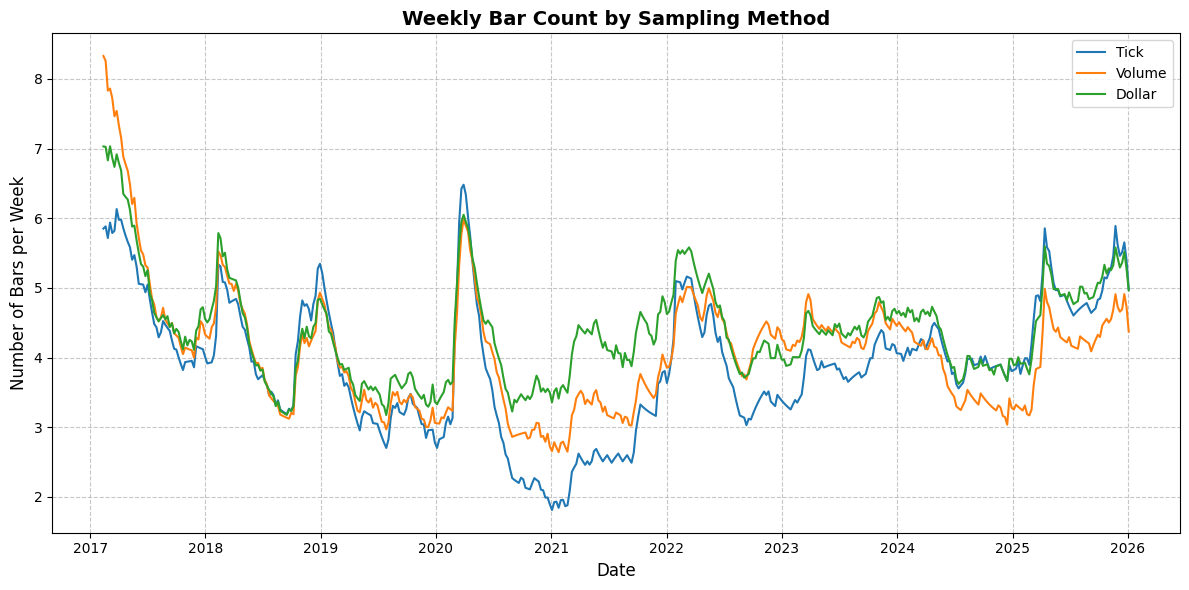

Stability Analysis (Coefficient of Variation):
            Mean       Std        CV
Dollar  4.366738  1.587155  0.363465
Volume  4.059701  1.671997  0.411852
Tick    3.891258  1.920122  0.493445


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_bar_stability(bars_dict: dict) -> pd.DataFrame:
    """
    Calculates weekly bar counts, plots the time series, and computes the 
    Coefficient of Variation (CV) for stability analysis.
    
    Parameters:
    bars_dict: dict mapping bar_type (str) to its corresponding DataFrame of bars.
               DataFrames must have a DatetimeIndex.
    """
    weekly_counts = {}
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for bar_type, df in bars_dict.items():
        if not isinstance(df.index, pd.DatetimeIndex):
            raise TypeError(f"Index of {bar_type} DataFrame must be a DatetimeIndex.")
            
        # Resample to weekly frequency and count the number of bars
        counts = df.resample('W').size()
        weekly_counts[bar_type] = counts
        counts = counts.ewm(span=20, adjust=True, min_periods=5).mean()  # Smooth the weekly counts for better 
        
        # Plotting
        ax.plot(counts.index, counts.values, label=bar_type, linewidth=1.5)
        
    ax.set_title("Weekly Bar Count by Sampling Method", fontsize=14, fontweight='bold')
    ax.set_ylabel("Number of Bars per Week", fontsize=12)
    ax.set_xlabel("Date", fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    fig.tight_layout()
    plt.show()
    
    # Calculate and display the Coefficient of Variation
    cv_results = {}
    for bar_type, counts in weekly_counts.items():
        mean_count = counts.mean()
        std_count = counts.std()
        cv = std_count / mean_count if mean_count > 0 else np.nan
        cv_results[bar_type] = {'Mean': mean_count, 'Std': std_count, 'CV': cv}
        
    cv_df = pd.DataFrame(cv_results).T
    print("Stability Analysis (Coefficient of Variation):")
    print(cv_df.sort_values('CV'))
    
    return cv_df


# Example usage (assuming tick_df, vol_df, dollar_df exist):
bars_dict = {'Tick': tick_bars, 'Volume': volume_bars, 'Dollar': dollar_bars}
stats_df = analyze_bar_stability(bars_dict)

In [286]:
import pandas as pd
import numpy as np

def compute_serial_correlation(bars_dict: dict) -> pd.DataFrame:
    """
    Computes the first-order serial correlation of log returns for given bar types.
    
    Parameters:
    bars_dict: dict mapping bar_type (str) to a DataFrame containing a 'Close' column.
    """
    results = {}
    
    for bar_type, df in bars_dict.items():
        if 'Close' not in df.columns:
            raise KeyError(f"DataFrame for {bar_type} must contain a 'Close' column.")
            
        # Compute log returns. 
        # Using log returns is non-negotiable for additive multi-period properties.
        returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()
        
        # Calculate lag-1 autocorrelation
        rho_1 = returns.autocorr(lag=1)
        
        # Calculate absolute autocorrelation (critical for microstructure evaluation)
        abs_rho_1 = np.abs(rho_1)
        
        results[bar_type] = {
            'rho_1': rho_1, 
            '|rho_1|': abs_rho_1,
            'Sample_Size': len(returns)
        }
        
    results_df = pd.DataFrame(results).T
    # Sort by the lowest absolute serial correlation
    return results_df.sort_values('|rho_1|')

# Example Usage:
bars_dict = {'Tick': tick_bars, 'Volume': volume_bars, 'Dollar': dollar_bars} #, 'Imbalance': imbalance_bars}
autocorr_stats = compute_serial_correlation(bars_dict)
print(autocorr_stats)



           rho_1   |rho_1|  Sample_Size
Volume -0.018350  0.018350       1903.0
Dollar  0.019810  0.019810       2047.0
Tick   -0.033907  0.033907       1824.0


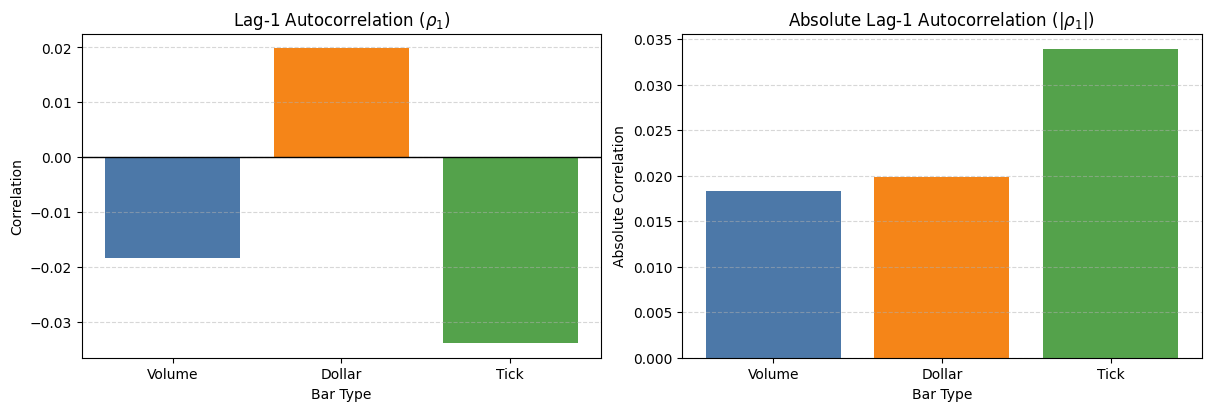

In [287]:
import matplotlib.pyplot as plt

# Plot serial correlation metrics by bar type
plot_df = autocorr_stats.copy()
plot_df.index = plot_df.index.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Signed lag-1 autocorrelation
axes[0].bar(plot_df.index, plot_df['rho_1'], color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Lag-1 Autocorrelation ($\\rho_1$)')
axes[0].set_ylabel('Correlation')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Absolute lag-1 autocorrelation (lower is better for microstructure noise)
axes[1].bar(plot_df.index, plot_df['|rho_1|'], color=['#4C78A8', '#F58518', '#54A24B'])
axes[1].set_title('Absolute Lag-1 Autocorrelation ($|\\rho_1|$)')
axes[1].set_ylabel('Absolute Correlation')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for ax in axes:
    ax.set_xlabel('Bar Type')

plt.show()

In [288]:
import pandas as pd
import numpy as np

def analyze_variance_stability(bars_dict: dict) -> pd.DataFrame:
    """
    Partitions bar series into monthly subsets, computes the variance of returns 
    for each month, and evaluates the stability of those variances.
    """
    results = {}
    
    for bar_type, df in bars_dict.items():
        if not isinstance(df.index, pd.DatetimeIndex):
            raise TypeError(f"Index of {bar_type} DataFrame must be a DatetimeIndex.")
            
        # 1. Compute log returns
        returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()
        
        # 2. Partition into monthly subsets and compute variance
        # pd.Grouper is highly efficient for DatetimeIndex partitioning
        monthly_variances = returns.groupby(pd.Grouper(freq='ME')).var()
        
        # Drop months with insufficient data (e.g., NaN variances due to N=1)
        monthly_variances = monthly_variances.dropna()
        
        # 3. Compute statistics on the variances
        var_of_vars = monthly_variances.var()
        mean_var = monthly_variances.mean()
        
        # Dimensionless stability metric
        cv_of_vars = np.sqrt(var_of_vars) / mean_var if mean_var > 0 else np.nan
        
        results[bar_type] = {
            'Mean_Monthly_Variance': mean_var,
            'Variance_of_Variances': var_of_vars,
            'CV_of_Variances': cv_of_vars
        }
        
    results_df = pd.DataFrame(results).T
    
    # Sort by the dimensionally correct metric, not the raw variance of variances
    return results_df.sort_values('CV_of_Variances')

# Example Usage:
# bars_dict = {'Tick': tick_df, 'Volume': vol_df, 'Dollar': dollar_df}
stability_stats = analyze_variance_stability(bars_dict)
print(stability_stats)

        Mean_Monthly_Variance  Variance_of_Variances  CV_of_Variances
Dollar               0.000118           1.672891e-08         1.100308
Volume               0.000132           2.460598e-08         1.187753
Tick                 0.000157           4.512536e-08         1.352533


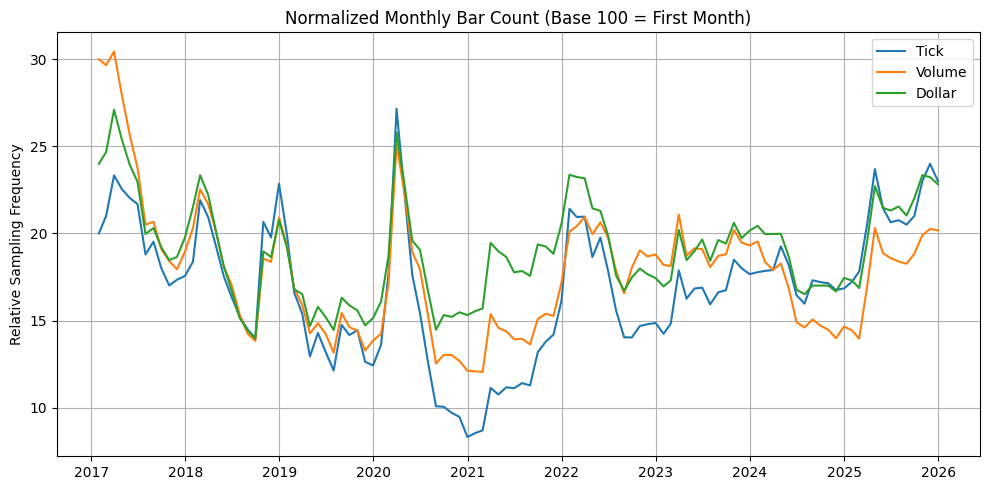

In [289]:
import matplotlib.pyplot as plt

def audit_sampling_heteroskedasticity(bars_dict: dict):
    """
    Plots the monthly bar counts. 
    If Dollar bars show a massive secular trend (up or down) compared to Tick/Volume,
    your threshold calibration is invalid.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    
    for bar_type, df in bars_dict.items():
        # Count number of bars per month
        monthly_counts = df.resample('ME').size()  # Smooth the monthly counts for better visualization
        monthly_counts = monthly_counts.ewm(span=5, adjust=False).mean()

        # Normalize to base 100 for direct comparison of drift
        # normalized_counts = (monthly_counts / monthly_counts.iloc[0]) * 100
        
        # ax.plot(normalized_counts.index, normalized_counts.values, label=bar_type)
        ax.plot(monthly_counts.index, monthly_counts.values, label=bar_type, linewidth=1.5)
        
    ax.set_title("Normalized Monthly Bar Count (Base 100 = First Month)")
    ax.set_ylabel("Relative Sampling Frequency")
    ax.legend()
    fig.tight_layout()
    plt.grid(True)
    plt.show()

# Run this:
audit_sampling_heteroskedasticity({'Tick': tick_bars, 'Volume': volume_bars, 'Dollar': dollar_bars})

In [290]:
import pandas as pd
import numpy as np
from scipy import stats

def compute_normality_tests(bars_dict: dict) -> pd.DataFrame:
    """
    Computes the Jarque-Bera test statistic for log returns of given bar types.
    WARNING: This comparison is mathematically invalid if lengths of returns (n) differ significantly.
    """
    results = {}
    
    for bar_type, df in bars_dict.items():
        if 'Close' not in df.columns:
            raise KeyError(f"DataFrame for {bar_type} must contain a 'Close' column.")
            
        # 1. Compute log returns
        returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()
        n = len(returns)
        
        # 2. Compute Skewness and Kurtosis (Fisher definition where Normal Kurtosis = 0)
        skewness = stats.skew(returns)
        # scipy.stats.kurtosis computes EXCESS kurtosis by default (K-3)
        excess_kurtosis = stats.kurtosis(returns, fisher=True) 
        
        # 3. Compute Jarque-Bera
        jb_stat, p_value = stats.jarque_bera(returns)
        
        results[bar_type] = {
            'N': n,
            'Skewness': skewness,
            'Excess_Kurtosis': excess_kurtosis,
            'JB_Statistic': jb_stat,
            'p_value': p_value
        }
        
    results_df = pd.DataFrame(results).T
    
    # Sort by lowest JB Statistic
    return results_df.sort_values('JB_Statistic')

# Example Usage:
# bars_dict = {'Tick': tick_df, 'Volume': vol_df, 'Dollar': dollar_df}
jb_stats = compute_normality_tests(bars_dict)
print(jb_stats)

             N  Skewness  Excess_Kurtosis  JB_Statistic  p_value
Volume  1903.0 -0.145168         4.659318   1728.046284      0.0
Dollar  2047.0 -0.488251         4.867464   2102.077891      0.0
Tick    1824.0  0.009399         5.486501   2287.755154      0.0


### Why this comparison is useful
Dollar bars sample the price process when a fixed notional amount has traded, so each observation represents a comparable amount of market activity rather than a fixed clock interval. In the next cell, we compare the raw 1-minute close series with the close series extracted from dollar bars to see how this sampling changes the time axis while preserving the underlying price dynamics.

Mathematically, a dollar bar closes when
$$
\sum_{i=T_{k-1}+1}^{T_k} p_i v_i \ge \theta_D,
$$
where $p_i$ is price, $v_i$ is volume, and $\theta_D$ is the dollar threshold.

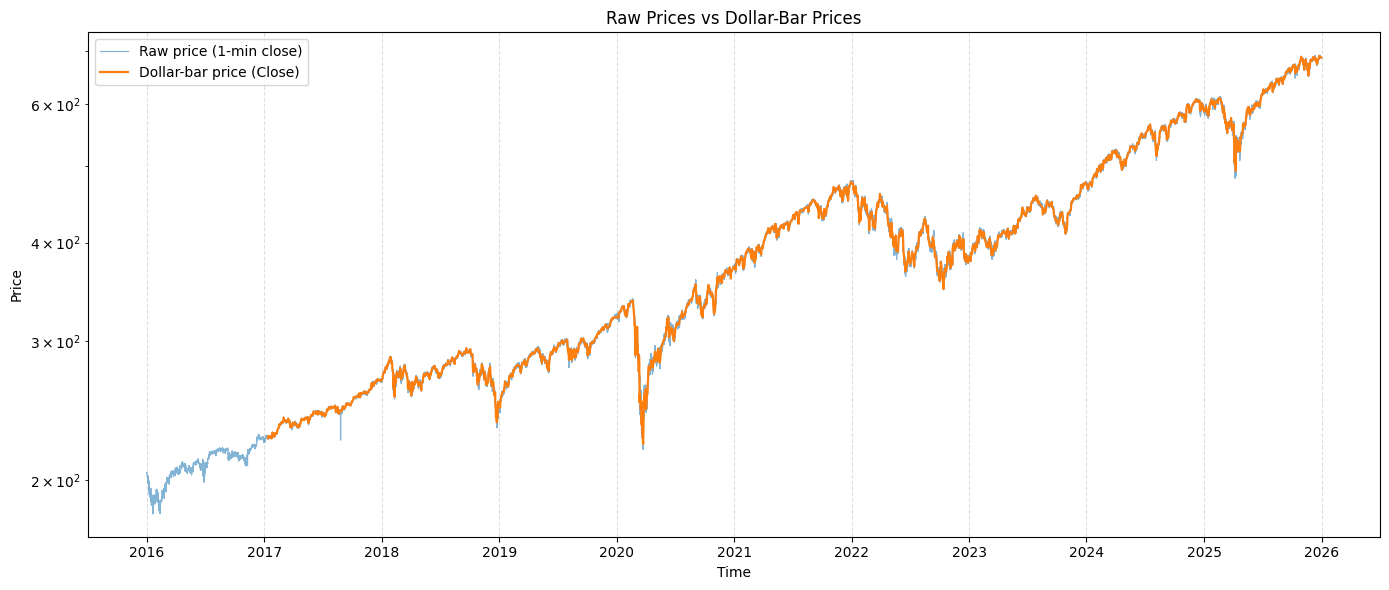

In [291]:
import pandas as pd
import matplotlib.pyplot as plt

# Build aligned price series
raw_prices = (
    df.loc[:, ["timestamp", "close"]]
    .assign(timestamp=lambda x: pd.to_datetime(x["timestamp"]))
    .set_index("timestamp")
    .sort_index()["close"]
)

dollar_prices = dollar_bars["Close"].sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.semilogy(raw_prices.index, raw_prices.values, label="Raw price (1-min close)", alpha=0.55, linewidth=0.9)
ax.semilogy(dollar_prices.index, dollar_prices.values, label="Dollar-bar price (Close)", linewidth=1.6)

ax.set_title("Raw Prices vs Dollar-Bar Prices")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()

### Why the return comparison is matched
The next cell compares log returns from dollar bars with a randomly matched sample of raw daily returns so that both series have the same sample size. This makes the Jarque-Bera and histogram comparison more interpretable, because the difference is then driven by the sampling scheme rather than by unequal observation counts.

Using log returns,
$$
r_t = \log\left(\frac{P_t}{P_{t-1}}\right),
$$
keeps multi-period moves additive and makes the distributional analysis easier to compare across bar types.

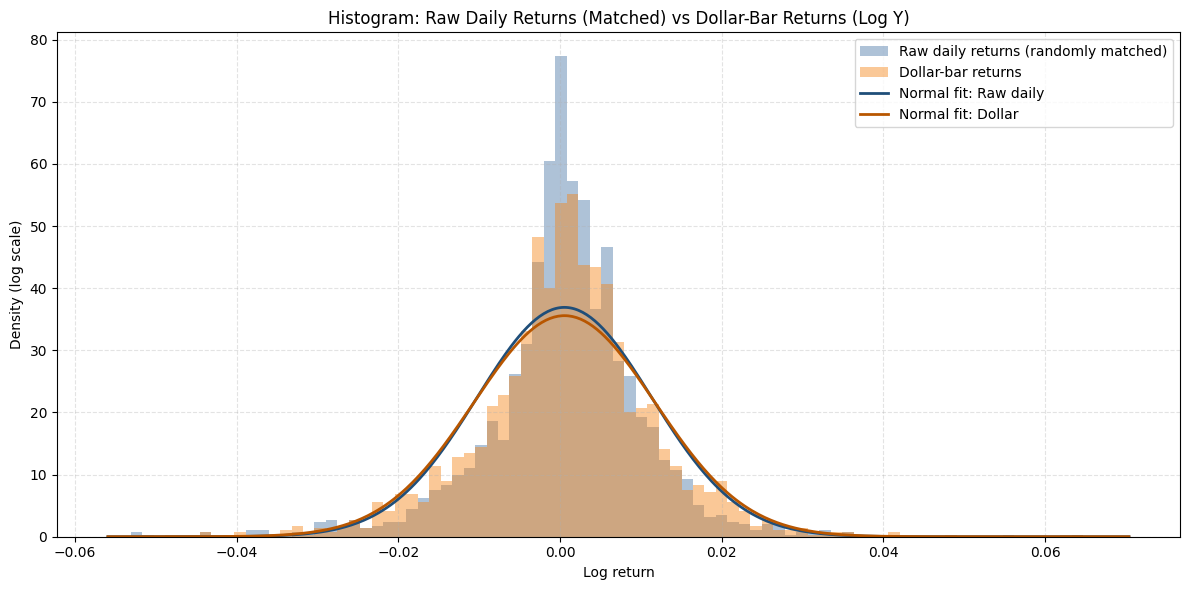

Normality statistics from compute_normality_tests (matched sample sizes):
                        N  Skewness  Excess_Kurtosis  JB_Statistic  p_value  \
Dollar             2047.0 -0.488251         4.867464   2102.077891      0.0   
Raw_daily_matched  2047.0 -0.084136        12.092104  12473.676442      0.0   

                   mu_normal_fit  sigma_normal_fit  
Dollar                  0.000543          0.011212  
Raw_daily_matched       0.000536          0.010808  


In [292]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Raw returns from daily close (not 1-minute)
raw_daily_close = (
    df.loc[:, ["timestamp", "close"]]
    .assign(timestamp=lambda x: pd.to_datetime(x["timestamp"]))
    .set_index("timestamp")
    .sort_index()["close"]
    .astype(float)
    .resample("1D")
    .last()
    .dropna()
)
raw_returns_full = np.log(raw_daily_close / raw_daily_close.shift(1)).dropna()

# Dollar-bar returns
dollar_returns = np.log(
    dollar_bars["Close"].astype(float) / dollar_bars["Close"].astype(float).shift(1)
).dropna()

# Randomly remove raw returns until sizes match dollar bars
n_target = len(dollar_returns)
if len(raw_returns_full) < n_target:
    raise ValueError(
        f"Not enough raw returns to downsample: raw={len(raw_returns_full)}, target={n_target}."
    )

rng = np.random.default_rng(42)
selected_idx = rng.choice(raw_returns_full.index.to_numpy(), size=n_target, replace=False)
raw_returns = raw_returns_full.loc[selected_idx].sort_index()

# Histogram support (trim extreme tails for readability)
q_low = min(raw_returns.quantile(0.001), dollar_returns.quantile(0.001))
q_high = max(raw_returns.quantile(0.999), dollar_returns.quantile(0.999))
bins = np.linspace(q_low, q_high, 90)
x = np.linspace(q_low, q_high, 500)

# Fit normal distributions
mu_raw, sigma_raw = stats.norm.fit(raw_returns)
mu_dol, sigma_dol = stats.norm.fit(dollar_returns)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(raw_returns, bins=bins, alpha=0.45, density=True, label="Raw daily returns (randomly matched)", color="#4C78A8")
ax.hist(dollar_returns, bins=bins, alpha=0.45, density=True, label="Dollar-bar returns", color="#F58518")

# Overlay fitted normal PDFs
ax.plot(x, stats.norm.pdf(x, mu_raw, sigma_raw), color="#1f4e79", linewidth=2.0, label="Normal fit: Raw daily")
ax.plot(x, stats.norm.pdf(x, mu_dol, sigma_dol), color="#b85600", linewidth=2.0, label="Normal fit: Dollar")

# ax.set_yscale("log")
ax.set_title("Histogram: Raw Daily Returns (Matched) vs Dollar-Bar Returns (Log Y)")
ax.set_xlabel("Log return")
ax.set_ylabel("Density (log scale)")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend()
fig.tight_layout()
plt.show()

# Use compute_normality_tests for statistics by reconstructing synthetic close series
raw_close_synth = np.concatenate([[1.0], np.exp(np.cumsum(raw_returns.to_numpy()))])
dollar_close_synth = np.concatenate([[1.0], np.exp(np.cumsum(dollar_returns.to_numpy()))])

bars_for_stats = {
    "Raw_daily_matched": pd.DataFrame({"Close": raw_close_synth}),
    "Dollar": pd.DataFrame({"Close": dollar_close_synth}),
}

jb_stats = compute_normality_tests(bars_for_stats)

# Add normal-fit parameters aligned by row labels
mu_map = {"Raw_daily_matched": mu_raw, "Dollar": mu_dol}
sigma_map = {"Raw_daily_matched": sigma_raw, "Dollar": sigma_dol}
jb_stats["mu_normal_fit"] = jb_stats.index.map(mu_map)
jb_stats["sigma_normal_fit"] = jb_stats.index.map(sigma_map)

print("Normality statistics from compute_normality_tests (matched sample sizes):")
print(jb_stats)

### Final output
The last cell writes the dollar-bar DataFrame to disk so the transformed series can be reused in later experiments without recomputing the bar construction. At this point, the notebook has already compared the raw series, checked normality, and summarized the bar-based returns.

In [293]:
dollar_bars.to_csv(r"G:\Mi unidad\2026\Tesis\Códigos\Data\sp500_2015_to_2025_dollar_bars.csv")